# Modelagem com Redes Neurais (PyTorch) e comparação com ensemble

Este notebook constrói a rede neural principal do projeto, compara o
resultado com um baseline de ensemble (Random Forest) e registra todos
os experimentos no MLflow. A lógica reutilizável (MLP, pipeline de
features, early stopping) vive em `src/`; o notebook apenas consome,
visualiza e documenta as decisões técnicas.

| Etapa | Onde |
|---|---|
| Imports e seeds | Célula 1 |
| Carga, split e pré-processamento | Célula 2 |
| Datasets PyTorch e DataLoaders | Célula 3 |
| Arquitetura MLP e early stopping | Célula 4 |
| Treinamento com `pos_weight` | Célula 5 |
| Curva de aprendizado | Célula 6 |
| Random Forest (baseline de ensemble) | Célula 7 |
| Tabela comparativa e tracking MLflow | Célula 8 |
| Curvas ROC e Precision-Recall | Célula 9 |
| Matrizes de confusão | Célula 10 |
| Trade-off de custo FP vs. FN | Célula 11 |
| Resumo final | Célula 12 |


---
## Célula 1 — Imports e configuração

Fixa as seeds (`torch`, `numpy`) antes de qualquer operação aleatória,
garantindo reprodutibilidade entre execuções. `PROJECT_ROOT` é
calculado a partir do diretório do notebook para que os imports de
`src/` funcionem independentemente de onde o Jupyter foi iniciado.


In [1]:
import sys
import os
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import mlflow
import mlflow.pytorch
import mlflow.sklearn
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    confusion_matrix,
    f1_score,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
)
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, Dataset

# Raiz do projeto: o notebook vive em notebooks/, sobe um nível.
PROJECT_ROOT = Path(os.getcwd()).resolve().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# Imports do projeto.
from src.utils.logger import get_logger
from src.data.loader import load_raw, clean
from src.features.pipeline import build_preprocessor, prepare_features

logger = get_logger("etapa2_notebook")

# Seeds fixadas antes de qualquer operação aleatória.
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

logger.info(
    "Imports OK. SEED=%d | PyTorch=%s | PROJECT_ROOT=%s",
    SEED, torch.__version__, PROJECT_ROOT,
)


2026-05-04 16:19:06 | INFO     | etapa2_notebook | Imports OK. SEED=42 | PyTorch=2.11.0+cpu | PROJECT_ROOT=F:\churn-prediction-pipeline


C:\Users\Pichau\AppData\Local\Programs\Python\Python313\Lib\site-packages\pandera\_pandas_deprecated.py:143: FutureWarning: Importing pandas-specific classes and functions from the
top-level pandera module will be **removed in a future version of pandera**.
If you're using pandera to validate pandas objects, we highly recommend updating
your import:

```
# old import
import pandera as pa

# new import
import pandera.pandas as pa
```

If you're using pandera to validate objects from other compatible libraries
like pyspark or polars, see the supported libraries section of the documentation
for more information on how to import pandera:

https://pandera.readthedocs.io/en/stable/supported_libraries.html

To disable this warning, set the environment variable:

```
export DISABLE_PANDERA_IMPORT_WARNING=True
```

  warnings.warn(_future_warning, FutureWarning)
INFO:etapa2_notebook:Imports OK. SEED=42 | PyTorch=2.11.0+cpu | PROJECT_ROOT=F:\churn-prediction-pipeline


---
## Célula 2 — Carga, split e pré-processamento

Reaproveita `load_raw`, `clean`, `prepare_features` e `build_preprocessor`
de `src/` para evitar duplicação de lógica entre notebook e produção.

**Por que `ColumnTransformer` em vez de `pd.get_dummies`?**
`get_dummies` não é serializável: a API não tem o DataFrame original
para reaplicar a transformação. O `ColumnTransformer` resolve isso —
faz `fit` no treino, é exportado em `joblib` e a inferência aplica
exatamente o mesmo `transform` em produção.

**Prevenção de data leakage:** o `fit` ocorre apenas no conjunto de
treino. Validação e teste recebem somente `transform`, espelhando o
cenário em que features novas chegam à API.

**Splits estratificados:** `stratify=y` mantém a proporção de churn
(~26%) constante entre treino, validação e teste. A divisão final é
70% / 10% / 20%.


In [2]:
df_raw = load_raw(PROJECT_ROOT / "data" / "raw" / "telco_churn.csv")
df = clean(df_raw)

logger.info(
    "Dataset shape: %s | Taxa de churn: %.2f%%",
    df.shape, df["Churn"].mean() * 100,
)

X, y = prepare_features(df)

# Splits 70/10/20 com stratify=y para manter a proporção de churn em cada fold.
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.125, random_state=SEED, stratify=y_trainval
)

logger.info(
    "Splits — treino: %d | val: %d | teste: %d",
    len(X_train), len(X_val), len(X_test),
)

# Fit apenas no treino, transform nos demais — evita data leakage.
preprocessor = build_preprocessor()
X_train_t = preprocessor.fit_transform(X_train).astype(np.float32)
X_val_t   = preprocessor.transform(X_val).astype(np.float32)
X_test_t  = preprocessor.transform(X_test).astype(np.float32)

y_train_arr = y_train.values.astype(np.float32)
y_val_arr   = y_val.values.astype(np.float32)
y_test_arr  = y_test.values.astype(np.float32)

INPUT_DIM = X_train_t.shape[1]
logger.info("Dimensão de entrada para a MLP: %d features", INPUT_DIM)


2026-05-04 16:19:06 | INFO     | src.data.loader | Carregando dataset de F:\churn-prediction-pipeline\data\raw\telco_churn.csv


INFO:src.data.loader:Carregando dataset de F:\churn-prediction-pipeline\data\raw\telco_churn.csv


2026-05-04 16:19:06 | INFO     | src.data.loader | Shape bruto: (7043, 21)


INFO:src.data.loader:Shape bruto: (7043, 21)


2026-05-04 16:19:06 | INFO     | src.data.loader | Limpeza OK. Shape: (7043, 20) | Churn rate: 26.5%


...

INFO:src.features.pipeline:Features separadas — X=(7043, 19) | y=(7043,)


2026-05-04 16:19:06 | INFO     | etapa2_notebook | Splits — treino: 4929 | val: 705 | teste: 1409


INFO:etapa2_notebook:Splits — treino: 4929 | val: 705 | teste: 1409


2026-05-04 16:19:06 | INFO     | etapa2_notebook | Dimensão de entrada para a MLP: 45 features


INFO:etapa2_notebook:Dimensão de entrada para a MLP: 45 features


---
## Célula 3 — Datasets PyTorch e DataLoaders

`Dataset` encapsula os arrays NumPy como tensores; `DataLoader` os
serve em mini-batches embaralhados a cada época. Treinar em batches
de 64 exemplos reduz o consumo de memória em relação ao batch
completo e tem efeito regularizador via ruído estocástico no
gradiente.


In [3]:
class TelcoDataset(Dataset):
    """Wrapper PyTorch sobre arrays NumPy ``(N, F)`` e ``(N,)``.

    O ``DataLoader`` consome instâncias desta classe para gerar
    mini-batches de tensores tipados ``float32``.
    """

    def __init__(self, features: np.ndarray, labels: np.ndarray) -> None:
        self.X = torch.tensor(features, dtype=torch.float32)
        self.y = torch.tensor(labels, dtype=torch.float32).unsqueeze(1)  # (N,) -> (N, 1)

    def __len__(self) -> int:
        return len(self.X)

    def __getitem__(self, idx: int):
        return self.X[idx], self.y[idx]


BATCH_SIZE = 64

train_loader = DataLoader(
    TelcoDataset(X_train_t, y_train_arr),
    batch_size=BATCH_SIZE,
    shuffle=True,
    drop_last=True,
)
val_loader = DataLoader(
    TelcoDataset(X_val_t, y_val_arr),
    batch_size=BATCH_SIZE,
    shuffle=False,
)

logger.info(
    "DataLoaders criados — %d batches de treino | %d batches de validação",
    len(train_loader), len(val_loader),
)


2026-05-04 16:19:06 | INFO     | etapa2_notebook | DataLoaders criados — 77 batches de treino | 12 batches de validação


INFO:etapa2_notebook:DataLoaders criados — 77 batches de treino | 12 batches de validação


---
## Célula 4 — Arquitetura MLP e Early Stopping

### Arquitetura

| Componente | Escolha | Justificativa |
|---|---|---|
| Camadas | `input → 64 → 32 → 16 → 1` | Redução gradual de dimensionalidade |
| Ativação | `ReLU` | Padrão consolidado para dados tabulares; mitiga vanishing gradient |
| `BatchNorm1d` | Após cada camada oculta | Estabiliza a distribuição de ativações e acelera convergência |
| `Dropout(0.3)` | Após `BatchNorm` | Regularização — desativa 30% dos neurônios em cada passo de treino |
| Saída | `Linear(16, 1)` sem sigmoid | Combinada com `BCEWithLogitsLoss` para estabilidade numérica |

### Early Stopping com restauração de pesos

O critério para de treinar quando `val_loss` deixa de melhorar por
`patience` épocas. A diferença em relação a uma versão básica é que
os pesos da **melhor** época são salvos e restaurados ao final — caso
contrário ficaríamos com os pesos da última época, que por construção
são piores que o ótimo observado.


In [4]:
class ChurnMLP(nn.Module):
    """MLP para classificação binária de churn.

    Arquitetura ``input → 64 → 32 → 16 → 1`` com BatchNorm, ReLU e Dropout.
    Saída em logit cru — combinada com ``BCEWithLogitsLoss`` no treino.
    """

    def __init__(self, input_dim: int, dropout: float = 0.3) -> None:
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, 1),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)


class EarlyStopping:
    """Early stopping com restauração dos pesos da melhor época."""

    def __init__(self, patience: int = 10, delta: float = 1e-4) -> None:
        self.patience  = patience
        self.delta     = delta
        self.best_loss: float    = float("inf")
        self.counter:   int      = 0
        self.should_stop: bool   = False
        self.best_weights: dict | None = None

    def step(self, val_loss: float, model: nn.Module) -> None:
        if val_loss < self.best_loss - self.delta:
            self.best_loss = val_loss
            self.counter   = 0
            self.best_weights = {k: v.clone() for k, v in model.state_dict().items()}
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.should_stop = True

    def restore_best(self, model: nn.Module) -> None:
        if self.best_weights is not None:
            model.load_state_dict(self.best_weights)
            logger.info("Pesos restaurados — melhor val_loss: %.4f", self.best_loss)


logger.info(
    "ChurnMLP e EarlyStopping definidos. Arquitetura: input(%d) → 64 → 32 → 16 → 1",
    INPUT_DIM,
)


2026-05-04 16:19:06 | INFO     | etapa2_notebook | ChurnMLP e EarlyStopping definidos. Arquitetura: input(45) → 64 → 32 → 16 → 1


INFO:etapa2_notebook:ChurnMLP e EarlyStopping definidos. Arquitetura: input(45) → 64 → 32 → 16 → 1


---
## Célula 5 — Treinamento com `pos_weight`

### Por que `pos_weight`

O dataset é desbalanceado (~26% de churn). Sem correção, o modelo
otimiza accuracy "respondendo a maioria" e nunca aprende a separar
churn. `pos_weight = n_negativos / n_positivos` informa à
`BCEWithLogitsLoss` que errar um caso positivo é proporcionalmente
mais caro. O valor é calculado a partir do próprio conjunto de
treino, evitando hardcode.

### `ReduceLROnPlateau`

Reduz o learning rate quando `val_loss` estagna. Permite passos
finais menores e converge melhor sem ajuste manual do `lr`. Atua de
forma complementar ao early stopping.


In [5]:
n_neg = (y_train_arr == 0).sum()
n_pos = (y_train_arr == 1).sum()
pos_weight_value = float(n_neg / n_pos)
logger.info(
    "pos_weight: %.2f (negativos=%d / positivos=%d)",
    pos_weight_value, n_neg, n_pos,
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
logger.info("Dispositivo de treino: %s", device)

model     = ChurnMLP(input_dim=INPUT_DIM, dropout=0.3).to(device)
criterion = nn.BCEWithLogitsLoss(
    pos_weight=torch.tensor([pos_weight_value], device=device)
)
optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5, factor=0.5)

early_stopping = EarlyStopping(patience=10)
history = {"train_loss": [], "val_loss": []}
EPOCHS = 100

for epoch in range(1, EPOCHS + 1):
    model.train()
    batch_losses = []
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        loss = criterion(model(X_batch), y_batch)
        loss.backward()
        optimizer.step()
        batch_losses.append(loss.item())
    train_loss = float(np.mean(batch_losses))

    model.eval()
    with torch.no_grad():
        val_losses = []
        for X_batch, y_batch in val_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            val_losses.append(criterion(model(X_batch), y_batch).item())
        val_loss = float(np.mean(val_losses))

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)

    scheduler.step(val_loss)
    early_stopping.step(val_loss, model)

    if epoch % 10 == 0 or epoch == 1:
        logger.info(
            "Época %3d/%d | train_loss=%.4f | val_loss=%.4f",
            epoch, EPOCHS, train_loss, val_loss,
        )

    if early_stopping.should_stop:
        logger.info("Early stopping acionado na época %d.", epoch)
        break

early_stopping.restore_best(model)
model.eval()

epochs_run = len(history["train_loss"])
best_epoch = int(np.argmin(history["val_loss"])) + 1
logger.info("Treino finalizado. Épocas: %d | Melhor época: %d", epochs_run, best_epoch)


2026-05-04 16:19:06 | INFO     | etapa2_notebook | pos_weight: 2.77 (negativos=3621 / positivos=1308)


INFO:etapa2_notebook:pos_weight: 2.77 (negativos=3621 / positivos=1308)


2026-05-04 16:19:06 | INFO     | etapa2_notebook | Dispositivo de treino: cpu


INFO:etapa2_notebook:Dispositivo de treino: cpu


2026-05-04 16:19:08 | INFO     | etapa2_notebook | Época   1/100 | train_loss=0.8442 | val_loss=0.6862


...

INFO:etapa2_notebook:Early stopping acionado na época 14.


2026-05-04 16:19:10 | INFO     | etapa2_notebook | Pesos restaurados — melhor val_loss: 0.6813


INFO:etapa2_notebook:Pesos restaurados — melhor val_loss: 0.6813


2026-05-04 16:19:10 | INFO     | etapa2_notebook | Treino finalizado. Épocas: 14 | Melhor época: 4


INFO:etapa2_notebook:Treino finalizado. Épocas: 14 | Melhor época: 4


---
## Célula 6 — Curva de aprendizado

Visualiza `train_loss` e `val_loss` por época. A linha pontilhada
marca a melhor época — onde os pesos foram restaurados. Divergência
crescente entre as duas curvas indica overfitting.


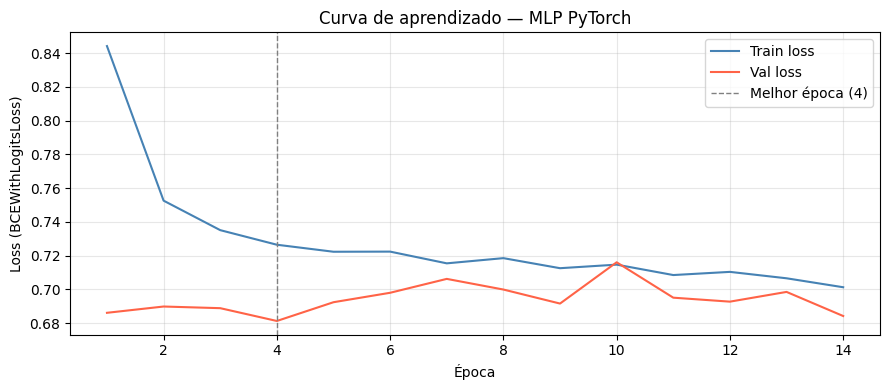

2026-05-04 16:19:10 | INFO     | etapa2_notebook | Curva salva. Melhor val_loss: 0.6813 na época 4


INFO:etapa2_notebook:Curva salva. Melhor val_loss: 0.6813 na época 4


In [6]:
fig, ax = plt.subplots(figsize=(9, 4))
epochs_axis = range(1, epochs_run + 1)

ax.plot(epochs_axis, history["train_loss"], label="Train loss", color="steelblue", linewidth=1.5)
ax.plot(epochs_axis, history["val_loss"],   label="Val loss",   color="tomato",    linewidth=1.5)
ax.axvline(best_epoch, color="gray", linestyle="--", linewidth=1, label=f"Melhor época ({best_epoch})")

ax.set_xlabel("Época")
ax.set_ylabel("Loss (BCEWithLogitsLoss)")
ax.set_title("Curva de aprendizado — MLP PyTorch")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("learning_curve.png", dpi=120, bbox_inches="tight")
plt.show()

logger.info("Curva salva. Melhor val_loss: %.4f na época %d", min(history["val_loss"]), best_epoch)

---
## Célula 7 — Random Forest como baseline de ensemble

O Random Forest treina múltiplas árvores em subconjuntos aleatórios
dos dados e agrega por votação. Serve como referência robusta
porque:

- É invariante à escala das features (não depende de normalização);
- Lida bem com dados tabulares com pouco ajuste de hiperparâmetros;
- `class_weight="balanced"` desempenha papel análogo ao `pos_weight`
  do PyTorch para o desbalanceamento de classes.


In [7]:
logger.info("Treinando Random Forest (baseline de ensemble)...")

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    class_weight="balanced",
    random_state=SEED,
    n_jobs=-1,
)
# Escalonado intencionalmente para que MLP e RF recebam a mesma entrada.
rf_model.fit(X_train_t, y_train_arr)

logger.info("Random Forest treinado com %d árvores.", rf_model.n_estimators)


2026-05-04 16:19:10 | INFO     | etapa2_notebook | Treinando Random Forest (baseline de ensemble)...


INFO:etapa2_notebook:Treinando Random Forest (baseline de ensemble)...


2026-05-04 16:19:10 | INFO     | etapa2_notebook | Random Forest treinado com 200 árvores.


INFO:etapa2_notebook:Random Forest treinado com 200 árvores.


---
## Célula 8 — Avaliação com 4 métricas e registro no MLflow

Avalia MLP e Random Forest no conjunto de teste e registra
parâmetros, métricas e artefatos no MLflow.

### Por que essas métricas

- **Accuracy:** referência geral; pouco informativa em dados desbalanceados.
- **F1-Score:** equilíbrio entre precision e recall — adequado para classe minoritária.
- **AUC-ROC:** mede separabilidade entre classes independente do threshold.
- **PR-AUC:** mais sensível que AUC-ROC quando a classe positiva é minoria.


In [8]:
def evaluate(y_true: np.ndarray, y_prob: np.ndarray, threshold: float = 0.5) -> dict:
    """Calcula accuracy, F1, AUC-ROC e PR-AUC para um vetor de probabilidades."""
    y_pred = (y_prob >= threshold).astype(int)
    return {
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "f1_score": float(f1_score(y_true, y_pred)),
        "roc_auc":  float(roc_auc_score(y_true, y_prob)),
        "pr_auc":   float(average_precision_score(y_true, y_prob)),
    }


# Predições MLP — sigmoid converte logit em probabilidade [0, 1].
with torch.no_grad():
    logits = model(torch.tensor(X_test_t).to(device))
    y_prob_mlp = torch.sigmoid(logits).cpu().numpy().squeeze()
y_pred_mlp = (y_prob_mlp >= 0.5).astype(int)
mlp_metrics = evaluate(y_test_arr, y_prob_mlp)

# Predições Random Forest.
y_prob_rf = rf_model.predict_proba(X_test_t)[:, 1]
y_pred_rf = rf_model.predict(X_test_t)
rf_metrics = evaluate(y_test_arr, y_prob_rf)

# Tabela comparativa de modelos.
comparison = pd.DataFrame(
    {"MLP PyTorch": mlp_metrics, "Random Forest": rf_metrics}
).T.round(4)
print("\n=== Tabela comparativa de modelos ===")
print(comparison.to_string())

# Tracking MLflow — registra MLP e Random Forest.
mlflow.set_experiment("Telco_Churn_Etapa2")

with mlflow.start_run(run_name="PyTorch_MLP"):
    mlflow.log_params({
        "architecture":            "64-32-16-1",
        "activation":              "ReLU",
        "loss_function":           "BCEWithLogitsLoss",
        "dropout":                 0.3,
        "epochs_run":              epochs_run,
        "best_epoch":              best_epoch,
        "batch_size":              BATCH_SIZE,
        "pos_weight":              round(pos_weight_value, 3),
        "optimizer":               "Adam",
        "lr":                      1e-3,
        "early_stopping_patience": 10,
        "seed":                    SEED,
    })
    mlflow.log_metrics(mlp_metrics)
    mlflow.log_metric("best_val_loss", min(history["val_loss"]))
    mlflow.pytorch.log_model(model, name="mlp_model")
    mlflow.log_artifact("learning_curve.png")
    logger.info("MLP registrado no MLflow.")

with mlflow.start_run(run_name="RandomForest_Ensemble"):
    mlflow.log_params({
        "n_estimators": 200,
        "class_weight": "balanced",
        "max_depth":    "None",
        "seed":         SEED,
    })
    mlflow.log_metrics(rf_metrics)
    mlflow.sklearn.log_model(rf_model, name="rf_model")
    logger.info("Random Forest registrado no MLflow.")



=== Tabela comparativa de modelos ===
               accuracy  f1_score  roc_auc  pr_auc
MLP PyTorch      0.7232    0.6045   0.8392  0.6294
Random Forest    0.7828    0.5364   0.8221  0.6145


2026/05/04 16:19:11 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.


2026-05-04 16:19:17 | INFO     | etapa2_notebook | MLP registrado no MLflow.


INFO:etapa2_notebook:MLP registrado no MLflow.


2026/05/04 16:19:17 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


2026-05-04 16:19:20 | INFO     | etapa2_notebook | Random Forest registrado no MLflow.


INFO:etapa2_notebook:Random Forest registrado no MLflow.


---
## Célula 9 — Curvas ROC e Precision-Recall

- **ROC:** quanto mais próxima do canto superior esquerdo, melhor.
  AUC corresponde à área sob a curva.
- **PR:** mais informativa em datasets desbalanceados. A linha
  pontilhada é o baseline aleatório, igual à taxa da classe positiva.


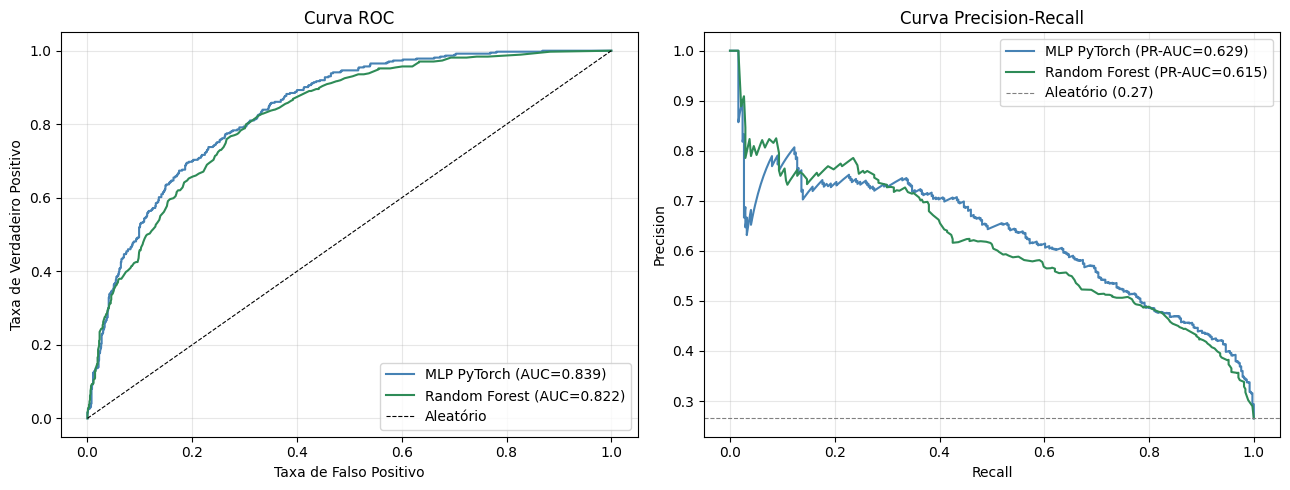

2026-05-04 16:19:21 | INFO     | etapa2_notebook | Curvas ROC e PR salvas.


INFO:etapa2_notebook:Curvas ROC e PR salvas.


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

models_to_plot = [
    ("MLP PyTorch",   y_prob_mlp, "steelblue"),
    ("Random Forest", y_prob_rf,  "seagreen"),
]

# Curva ROC
for name, y_prob, color in models_to_plot:
    fpr, tpr, _ = roc_curve(y_test_arr, y_prob)
    auc = roc_auc_score(y_test_arr, y_prob)
    axes[0].plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})", color=color)
axes[0].plot([0, 1], [0, 1], "k--", linewidth=0.8, label="Aleatório")
axes[0].set_xlabel("Taxa de Falso Positivo")
axes[0].set_ylabel("Taxa de Verdadeiro Positivo")
axes[0].set_title("Curva ROC")
axes[0].legend()
axes[0].grid(alpha=0.3)

# Curva Precision-Recall
for name, y_prob, color in models_to_plot:
    prec, rec, _ = precision_recall_curve(y_test_arr, y_prob)
    pr_auc = average_precision_score(y_test_arr, y_prob)
    axes[1].plot(rec, prec, label=f"{name} (PR-AUC={pr_auc:.3f})", color=color)
baseline_pr = y_test_arr.mean()  # um modelo aleatório acerta na proporção da classe positiva
axes[1].axhline(baseline_pr, color="gray", linestyle="--", linewidth=0.8,
                label=f"Aleatório ({baseline_pr:.2f})")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title("Curva Precision-Recall")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("roc_pr_curves.png", dpi=120, bbox_inches="tight")
plt.show()
logger.info("Curvas ROC e PR salvas.")

---
## Célula 10 — Matrizes de Confusão

Cada célula exibe contagem absoluta e percentual sobre o total. O
quadrante inferior esquerdo (Falsos Negativos) é o erro mais caro do
ponto de vista de negócio: clientes que cancelaram sem que o modelo
identificasse o risco.


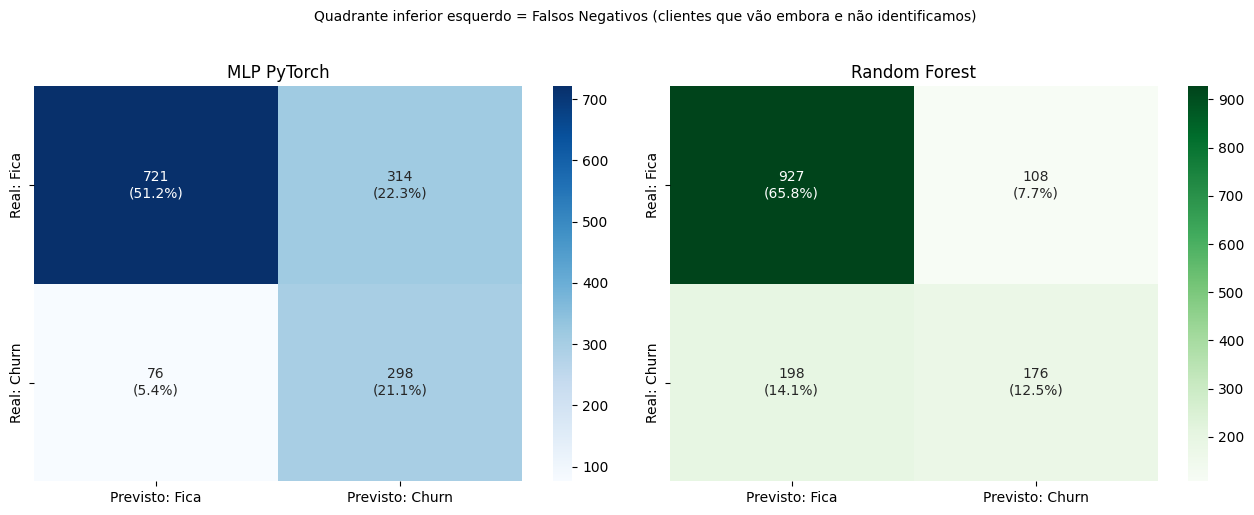

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, y_pred, title, cmap in [
    (axes[0], y_pred_mlp, "MLP PyTorch",   "Blues"),
    (axes[1], y_pred_rf,  "Random Forest", "Greens"),
]:
    cm = confusion_matrix(y_test_arr, y_pred)
    # Anotação: contagem + percentual do total
    labels = [[f"{v}\n({v / cm.sum() * 100:.1f}%)" for v in row] for row in cm]
    sns.heatmap(
        cm, annot=labels, fmt="", cmap=cmap, ax=ax,
        xticklabels=["Previsto: Fica", "Previsto: Churn"],
        yticklabels=["Real: Fica", "Real: Churn"],
    )
    ax.set_title(title)

plt.suptitle(
    "Quadrante inferior esquerdo = Falsos Negativos (clientes que vão embora e não identificamos)",
    fontsize=10, y=1.02,
)
plt.tight_layout()
plt.savefig("confusion_matrices.png", dpi=120, bbox_inches="tight")
plt.show()

---
## Célula 11 — Trade-off de custo (FP vs. FN)

Traduz os erros do modelo em impacto financeiro. As premissas abaixo
são parametrizáveis; a operadora deve calibrá-las com dados reais de
LTV e custo de campanha.

- **Custo FP (R$ 50):** ação de retenção desnecessária para um cliente
  que iria permanecer.
- **Custo FN (R$ 500):** perda de receita futura por não agir sobre um
  cliente que cancelou.


In [11]:
CUSTO_FP = 50.0
CUSTO_FN = 500.0


def custo_total(
    y_true: np.ndarray,
    y_pred: np.ndarray,
    custo_fp: float,
    custo_fn: float,
) -> dict:
    """Traduz a matriz de confusão em custo total e recall sobre a classe churn."""
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    total_cost = fp * custo_fp + fn * custo_fn
    recall_churn = tp / max(tp + fn, 1)
    return {
        "TP": int(tp), "TN": int(tn), "FP": int(fp), "FN": int(fn),
        "Custo FP (R$)":      fp * custo_fp,
        "Custo FN (R$)":      fn * custo_fn,
        "Custo Total (R$)":   total_cost,
        "Churn detectado (%)": round(recall_churn * 100, 1),
    }


cost_mlp = custo_total(y_test_arr, y_pred_mlp, CUSTO_FP, CUSTO_FN)
cost_rf  = custo_total(y_test_arr, y_pred_rf,  CUSTO_FP, CUSTO_FN)

cost_df = pd.DataFrame({"MLP PyTorch": cost_mlp, "Random Forest": cost_rf}).T
print("\n=== Análise de Custo de Negócio ===")
print(f"Premissas: Custo FP = R${CUSTO_FP:.0f} | Custo FN = R${CUSTO_FN:.0f}")
print(cost_df.to_string())

melhor = (
    "MLP PyTorch"
    if cost_mlp["Custo Total (R$)"] < cost_rf["Custo Total (R$)"]
    else "Random Forest"
)
economia = abs(cost_mlp["Custo Total (R$)"] - cost_rf["Custo Total (R$)"])

logger.info("Melhor modelo por custo: %s | Economia: R$%.0f", melhor, economia)
print(f"\n>>> Melhor modelo por custo de negócio: {melhor}")
print(f">>> Economia potencial: R${economia:,.0f} em relação ao outro modelo")



=== Análise de Custo de Negócio ===
Premissas: Custo FP = R$50 | Custo FN = R$500
                  TP     TN     FP     FN  Custo FP (R$)  Custo FN (R$)  Custo Total (R$)  Churn detectado (%)
MLP PyTorch    298.0  721.0  314.0   76.0        15700.0        38000.0           53700.0                 79.7
Random Forest  176.0  927.0  108.0  198.0         5400.0        99000.0          104400.0                 47.1
2026-05-04 16:19:21 | INFO     | etapa2_notebook | Melhor modelo por custo: MLP PyTorch | Economia: R$50700


INFO:etapa2_notebook:Melhor modelo por custo: MLP PyTorch | Economia: R$50700



>>> Melhor modelo por custo de negócio: MLP PyTorch
>>> Economia potencial: R$50,700 em relação ao outro modelo


---
## Célula 12 — Resumo

Consolida métricas, artefatos visuais e indica os próximos passos do
projeto (refatoração para `src/`, API FastAPI, testes e Makefile).


In [12]:
print("=" * 55)
print("RESUMO — ETAPA 2")
print("=" * 55)

print(f"\nMLP PyTorch (arquitetura: input → 64 → 32 → 16 → 1)")
print(f"  Épocas rodadas : {epochs_run} | Melhor época: {best_epoch}")
print(f"  Melhor val_loss: {min(history['val_loss']):.4f}")
for k, v in mlp_metrics.items():
    print(f"  {k:12s}: {v:.4f}")

print(f"\nRandom Forest (200 árvores, class_weight=balanced)")
for k, v in rf_metrics.items():
    print(f"  {k:12s}: {v:.4f}")

print("\nArtefatos gerados:")
print("  - learning_curve.png    (curva de aprendizado)")
print("  - roc_pr_curves.png     (curvas ROC e PR)")
print("  - confusion_matrices.png (matrizes de confusão)")
print("  - Modelos no MLflow → rode: mlflow ui --port 5000")

print("\nPróximos passos (Etapa 3):")
print("  - Refatorar código em src/models/mlp.py")
print("  - Construir API FastAPI com /predict e /health")
print("  - Escrever testes pytest (smoke, schema, API)")
print("  - Configurar ruff e Makefile")

logger.info("Etapa 2 concluída com sucesso.")

RESUMO — ETAPA 2

MLP PyTorch (arquitetura: input → 64 → 32 → 16 → 1)
  Épocas rodadas : 14 | Melhor época: 4
  Melhor val_loss: 0.6813
  accuracy    : 0.7232
  f1_score    : 0.6045
  roc_auc     : 0.8392
  pr_auc      : 0.6294

Random Forest (200 árvores, class_weight=balanced)
  accuracy    : 0.7828
  f1_score    : 0.5364
  roc_auc     : 0.8221
  pr_auc      : 0.6145

Artefatos gerados:
  - learning_curve.png    (curva de aprendizado)
  - roc_pr_curves.png     (curvas ROC e PR)
  - confusion_matrices.png (matrizes de confusão)
  - Modelos no MLflow → rode: mlflow ui --port 5000

Próximos passos (Etapa 3):
  - Refatorar código em src/models/mlp.py
  - Construir API FastAPI com /predict e /health
  - Escrever testes pytest (smoke, schema, API)
  - Configurar ruff e Makefile
2026-05-04 16:19:21 | INFO     | etapa2_notebook | Etapa 2 concluída com sucesso.


INFO:etapa2_notebook:Etapa 2 concluída com sucesso.
